In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load all 4 CSVs
df_events = pd.read_csv("data/marvel_events.csv")
df_weather = pd.read_csv("data/melbourne_weather.csv")
df_afl = pd.read_csv("data/afl_games.csv")
df_holidays = pd.read_csv("data/public_holidays.csv")

print("Events:", df_events.shape)
print("Weather:", df_weather.shape)
print("AFL:", df_afl.shape)
print("Holidays:", df_holidays.shape)

Events: (76, 4)
Weather: (1096, 4)
AFL: (16966, 1)
Holidays: (76, 2)


In [2]:
print("=== EVENTS ===")
print(df_events.head())

print("\n=== WEATHER ===")
print(df_weather.head())

print("\n=== AFL ===")
print(df_afl.head())

print("\n=== HOLIDAYS ===")
print(df_holidays.head())

=== EVENTS ===
                                                name        date  genre  \
0  Post Malone's BIG ASS World Tour - With Don To...  2026-10-09  Music   
1                   Harry Styles: Together, Together  2026-11-27  Music   
2                   Harry Styles: Together, Together  2026-11-28  Music   
3                   Harry Styles: Together, Together  2026-12-02  Music   
4                   Harry Styles: Together, Together  2026-12-04  Music   

                                                 url  
0  https://www.ticketmaster.com.au/post-malones-b...  
1  https://www.ticketmaster.com.au/harry-styles-t...  
2  https://www.ticketmaster.com.au/harry-styles-t...  
3  https://www.ticketmaster.com.au/harry-styles-t...  
4  https://www.ticketmaster.com.au/harry-styles-t...  

=== WEATHER ===
         time  temperature_2m_max  precipitation_sum  windspeed_10m_max
0  2022-01-01                36.7                0.2               21.9
1  2022-01-02                30.0          

In [3]:
# Re-read AFL with correct separator and skip the header row
df_afl = pd.read_csv("data/afl_games.csv", 
                      sep="\s+",        # split on whitespace
                      skiprows=1,       # skip the title row
                      header=None,      # no header in the data
                      on_bad_lines="skip",
                      engine="python")

print(df_afl.shape)
print(df_afl.head())

(11010, 9)
     0            1   2            3        4            5       6          7  \
0  1.0   8-May-1897  R1      Fitzroy  6.13.49      Carlton  2.4.16  Brunswick   
1  3.0   8-May-1897  R1      Geelong   3.6.24     Essendon  7.5.47      Corio   
2  6.0  15-May-1897  R2     Essendon   4.6.30  Collingwood  8.2.50       East   
3  8.0  15-May-1897  R2    Melbourne  9.10.64      Geelong  3.1.19     M.C.G.   
4  9.0  22-May-1897  R3  Collingwood   6.5.41      Geelong  5.7.37   Victoria   

           8  
0         St  
1       Oval  
2  Melbourne  
3        NaN  
4       Park  


In [4]:
# Name the columns
df_afl.columns = ["game_num", "date", "round", "home_team", "home_score", "away_team", "away_score", "venue_part1", "venue_part2"]

# Combine the split venue columns
df_afl["venue"] = df_afl["venue_part1"].fillna("") + " " + df_afl["venue_part2"].fillna("")
df_afl["venue"] = df_afl["venue"].str.strip()

# Drop the split columns
df_afl = df_afl.drop(columns=["venue_part1", "venue_part2"])

# Filter only Marvel Stadium / Docklands games
marvel_names = ["Marvel", "Docklands", "Etihad"]  # stadium has had multiple names!
df_afl_marvel = df_afl[df_afl["venue"].str.contains("|".join(marvel_names), na=False)]

print(f"Total AFL games: {len(df_afl)}")
print(f"Games at Marvel/Docklands/Etihad: {len(df_afl_marvel)}")
print(df_afl_marvel.head())

Total AFL games: 11010
Games at Marvel/Docklands/Etihad: 962
      game_num         date round  home_team home_score  away_team away_score  \
7386   11729.0   9-Mar-2000    R1   Essendon  24.12.156       Port   Adelaide   
7389   11733.0  12-Mar-2000    R1         St      Kilda  15.10.100     Sydney   
7402   11752.0  31-Mar-2000    R4  Kangaroos  15.14.104    Geelong    15.9.99   
7403   11753.0   1-Apr-2000    R4    Western   Bulldogs   14.14.98    Carlton   
7407   11757.0   2-Apr-2000    R4   Richmond    13.9.87  Fremantle   12.16.88   

                   venue  
7386   8.14.62 Docklands  
7389  21.8.134 Docklands  
7402           Docklands  
7403   8.11.59 Docklands  
7407           Docklands  


In [5]:
# Fix venue — keep only the last word (actual venue name)
df_afl_marvel = df_afl_marvel.copy()
df_afl_marvel["venue"] = df_afl_marvel["venue"].str.strip().str.split().str[-1]

# Fix date format to match our other datasets (YYYY-MM-DD)
df_afl_marvel["date"] = pd.to_datetime(df_afl_marvel["date"], format="%d-%b-%Y")
df_afl_marvel["date"] = df_afl_marvel["date"].dt.strftime("%Y-%m-%d")

# Filter to 2022-2024 to match our weather data range
df_afl_marvel = df_afl_marvel[df_afl_marvel["date"] >= "2022-01-01"]

print(f"AFL games at Marvel (2022-2024): {len(df_afl_marvel)}")
print(df_afl_marvel.head())

AFL games at Marvel (2022-2024): 150
       game_num        date round home_team home_score away_team   away_score  \
10423   15986.0  2022-03-18    R1        St      Kilda  12.13.85  Collingwood   
10427   15993.0  2022-03-24    R2   Western   Bulldogs  13.12.90      Carlton   
10430   15996.0  2022-03-26    R2  Essendon   10.15.75  Brisbane        Lions   
10433   16002.0  2022-03-31    R3   Western   Bulldogs   9.17.71       Sydney   
10437   16009.0  2022-04-03    R3        St      Kilda  18.9.117     Richmond   

           venue  
10423  Docklands  
10427  Docklands  
10430  Docklands  
10433  Docklands  
10437  Docklands  


In [6]:
# Check for any remaining issues
print("Any nulls?")
print(df_afl_marvel.isnull().sum())

# Save cleaned AFL data
df_afl_marvel.to_csv("data/afl_marvel_clean.csv", index=False)
print("\n✅ Saved cleaned AFL data!")

# Also fix weather column name for consistency
df_weather = df_weather.rename(columns={"time": "date"})
df_weather.to_csv("data/melbourne_weather.csv", index=False)
print("✅ Saved cleaned weather data!")

# Fix holidays - filter to VIC only (remove ACT, SA etc)
df_holidays = df_holidays[
    df_holidays["name"].str.contains("New Year|Australia Day|Labour Day|Easter|Christmas|Melbourne Cup|AFL", na=False)
]
df_holidays.to_csv("data/public_holidays.csv", index=False)
print("✅ Saved cleaned holidays data!")

print("\nAll datasets cleaned and saved! 🎉")

Any nulls?
game_num      0
date          0
round         0
home_team     0
home_score    0
away_team     0
away_score    0
venue         0
dtype: int64

✅ Saved cleaned AFL data!
✅ Saved cleaned weather data!
✅ Saved cleaned holidays data!

All datasets cleaned and saved! 🎉


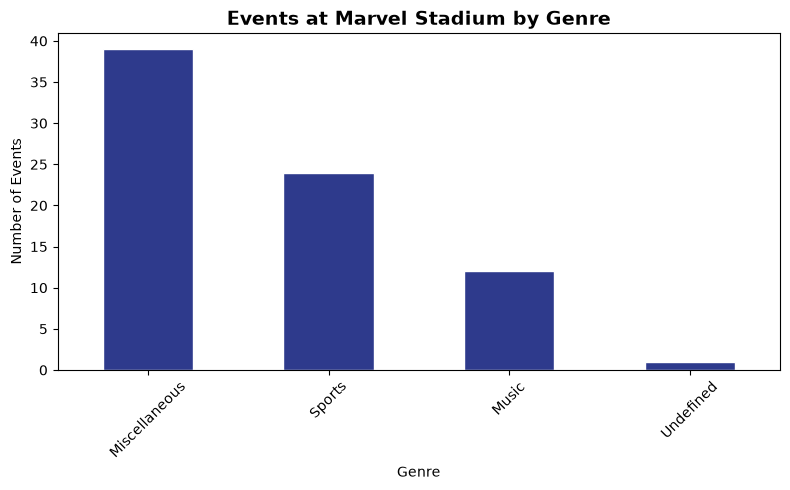

✅ Chart 1 saved!


In [7]:
plt.figure(figsize=(8, 5))
df_events["genre"].value_counts().plot(kind="bar", color="#2E3A8C", edgecolor="white")
plt.title("Events at Marvel Stadium by Genre", fontsize=14, fontweight="bold")
plt.xlabel("Genre")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("data/chart1_genre.png", dpi=150)
plt.show()
print("✅ Chart 1 saved!")

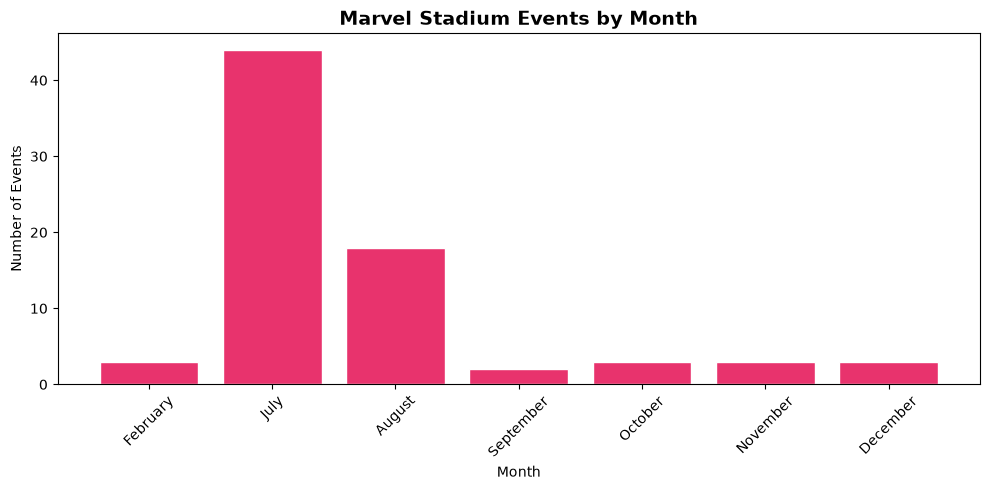

✅ Chart 2 saved!


In [8]:
df_events["date"] = pd.to_datetime(df_events["date"])
df_events["month"] = df_events["date"].dt.month_name()
df_events["month_num"] = df_events["date"].dt.month

monthly = df_events.groupby(["month_num", "month"]).size().reset_index(name="count")
monthly = monthly.sort_values("month_num")

plt.figure(figsize=(10, 5))
plt.bar(monthly["month"], monthly["count"], color="#E8336D", edgecolor="white")
plt.title("Marvel Stadium Events by Month", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("data/chart2_monthly.png", dpi=150)
plt.show()
print("✅ Chart 2 saved!")

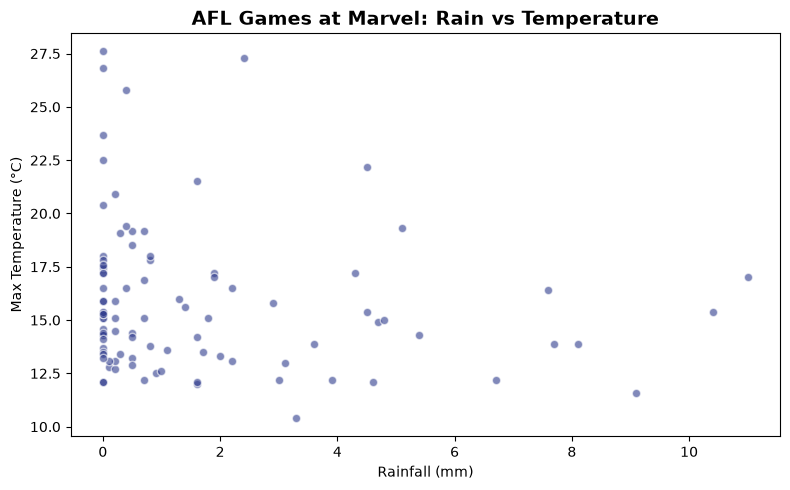

✅ Chart 3 saved!


In [9]:
# Merge AFL games with weather on date
df_afl_marvel = pd.read_csv("data/afl_marvel_clean.csv")
df_weather = pd.read_csv("data/melbourne_weather.csv")

df_afl_weather = pd.merge(df_afl_marvel, df_weather, on="date", how="left")

plt.figure(figsize=(8, 5))
plt.scatter(df_afl_weather["precipitation_sum"], 
            df_afl_weather["temperature_2m_max"],
            color="#2E3A8C", alpha=0.6, edgecolors="white")
plt.title("AFL Games at Marvel: Rain vs Temperature", fontsize=14, fontweight="bold")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Max Temperature (°C)")
plt.tight_layout()
plt.savefig("data/chart3_weather.png", dpi=150)
plt.show()
print("✅ Chart 3 saved!")

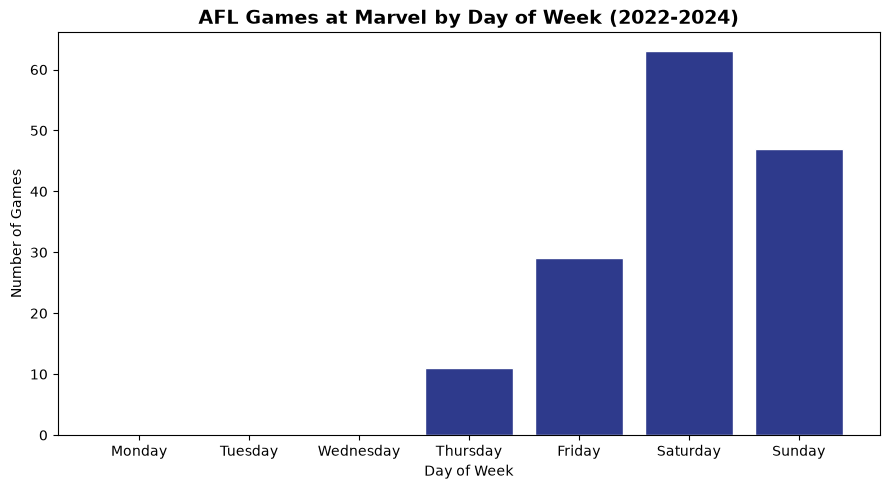

✅ Chart 4 saved!


In [10]:
df_afl_marvel = pd.read_csv("data/afl_marvel_clean.csv")
df_afl_marvel["date"] = pd.to_datetime(df_afl_marvel["date"])
df_afl_marvel["day_of_week"] = df_afl_marvel["date"].dt.day_name()

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_counts = df_afl_marvel["day_of_week"].value_counts().reindex(day_order).fillna(0)

plt.figure(figsize=(9, 5))
plt.bar(day_counts.index, day_counts.values, color="#2E3A8C", edgecolor="white")
plt.title("AFL Games at Marvel by Day of Week (2022-2024)", fontsize=14, fontweight="bold")
plt.xlabel("Day of Week")
plt.ylabel("Number of Games")
plt.tight_layout()
plt.savefig("data/chart4_dayofweek.png", dpi=150)
plt.show()
print("✅ Chart 4 saved!")